The 1st order equation in block matrix form is given by:

\begin{equation*}
\begin{bmatrix}
HL & C^T R \\
R^T C & 0 
\end{bmatrix}
\begin{pmatrix}
s_1 \\
f_1
\end{pmatrix} =
\begin{pmatrix}
r_1 \\
r_2
\end{pmatrix}
\end{equation*} 

where 
\begin{align*}
r_1 &= CD_s\Sigma_1  \\
r_2 &= \frac{i}{2} X - R^T G L^{-1} R n \cdot i X
\end{align*}

Using block LU decomposition, we have:

\begin{align*}
HLs_1^* &=  r_1 \\
S f_1^* &= r_2 - R^T C s_1^* \\
f_1 &= f_1^* \\
s_1 &= s_1^* + (HL)^{-1} C^T
\end{align*}

where $S = - R^T C (HL)^{-1} C^T R$ is the Schur complement.

In [1]:
using ImmersedLayers
using Plots
using UnPack
using Interpolations
using ViscousStreaming
using Revise

In [2]:
# markdown display disable
import Markdown
Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [3]:
DDF_TYPE = CartesianGrids.Yang3

CartesianGrids.Yang3

set up exact solution

In [4]:
Re = 40
ϵ = 0.1
p = ViscousStreaming.StreamingParams(ϵ,Re)

Streaming flow parameters with Re = 40.0, ϵ = 0.1


In [5]:
sol_iner = ViscousStreaming.StreamingAnalytical(p, InertialFrame);

Maximum residual on W₁ = 5.684341886080802e-14
BC residual on Ψ₁(1) = 1.1443916996305594e-16
BC residual on dΨ₁(1) = 2.2887833992611187e-16
Maximum residual on Ws₂ = 3.979039320256561e-13
BC residual on Ψs₂(1) = 3.552713678800501e-15
BC residual on dΨs₂(1) = 2.6645352591003757e-15
Verifying second-order oscillatory solution...
Maximum residual on W₂ = 1.67181510390182e-12
BC residual on Ψ₂(1) = 2.8609792490763984e-17
BC residual on dΨ₂(1) = 2.220446049250313e-15


1st order solution

In [6]:
_get_helmholtz(coeff_factor::Real,α::Real,g::PhysicalGrid,with_inverse,::Type{IndexScaling}) =
               CartesianGrids.plan_helmholtz(g,with_inverse=with_inverse,factor=coeff_factor)
_get_helmholtz(coeff_factor::Real,α::Real,g::PhysicalGrid,with_inverse,::Type{GridScaling}) =
               CartesianGrids.plan_helmholtz(g,α*cellsize(g)^2,with_inverse=with_inverse,factor=coeff_factor/cellsize(g)^2)

_get_helmholtz (generic function with 2 methods)

In [16]:
function create_CHLinvCT(cache::BasicILMCache{N}, H;scale=1.0) where {N}
    @unpack L, sdata_cache, gdata_cache, gcurl_cache = cache

    len = length(sdata_cache)
    A = Matrix{eltype(sdata_cache)}(undef,len,len)
    fill!(sdata_cache,0.0)

    for col in 1:len
        sdata_cache[col] = 1.0
        fill!(gdata_cache,0.0)
        fill!(gcurl_cache,0.0)

        surface_curl!(gcurl_cache,sdata_cache,cache)
        gcurl_cache .= H \ gcurl_cache
        inverse_laplacian!(gcurl_cache,cache)
        
        surface_curl!(sdata_cache,gcurl_cache,cache)

        A[:,col] = scale*sdata_cache
        fill!(sdata_cache,0.0)
    end

    return -A

end

create_CHLinvCT (generic function with 2 methods)

In [8]:
@ilmproblem ViscousStreaming vector

In [ ]:
struct ViscousStreamingCache{SMT,SSMT,CMT,RCT,DVT,VNT,ST,VFT,FT, HT} <: AbstractExtraILMCache
   S :: SMT
   Ss :: SSMT
   C :: CMT
   Rc :: RCT
   dv :: DVT
   vb :: DVT
   vprime :: DVT
   dvn :: VNT
   sstar :: ST
   vϕ :: VFT
   ϕ :: FTe
   H :: HT # Helmholtz operator
end

In [ ]:
function ImmersedLayers.prob_cache(prob::ViscousStreamingProblem,base_cache::BasicILMCache)
    # Build Helmholtz operator with Re from phys_params
    Re = prob.phys_params["Re"]
    H = _get_helmholtz(1.0, Re, base_cache.g, true, GridScaling)

    S = create_CHLinvCT(base_cache, H)
    Ss = create_CLinvCT_scalar(base_cache)
    C = create_surface_filter(base_cache)

    dv = zeros_surface(base_cache)
    vb = zeros_surface(base_cache)
    vprime = zeros_surface(base_cache)

    dvn = ScalarData(dv)
    sstar = zeros_gridcurl(base_cache)
    vϕ = zeros_grid(base_cache)
    ϕ = Nodes(Primal,sstar)

    Rc = RegularizationMatrix(base_cache,dvn,ϕ)



    ViscousStreamingCache(S,Ss,C,Rc,dv,vb,vprime,dvn,sstar,vϕ,ϕ,H)
end

In [ ]:
function ImmersedLayers.solve(prob::ViscousStreamingProblem,sys::ILMSystem)
    @unpack extra_cache, base_cache, bc, phys_params = sys
    @unpack nrm = base_cache
    @unpack S, Ss, C, Rc, dv, vb, vprime, sstar, dvn, vϕ, ϕ, H  = extra_cache

    σ = zeros_surface(sys)
    s = zeros_gridcurl(sys)
    v = zeros_grid(sys)

    # Get the jumps in velocity across surface
    prescribed_surface_jump!(dv,sys)

    # Compute r1
    surface_divergence_symm!(v,dv,sys)
    curl!(sstar,v,sys)

    # Compute ψ*
    sstar .= H \ sstar
    inverse_laplacian!(sstar,sys) 

    # Adjustment for jump in normal velocity
    pointwise_dot!(dvn,nrm,dv)
    regularize!(ϕ,dvn,Rc)
    inverse_laplacian!(ϕ,sys)
    grad!(vϕ,ϕ,sys)

    # Get the average velocity on the surface
    prescribed_surface_average!(vb,sys)
    ImmersedLayers.interpolate!(vprime,vϕ,sys)
    vprime .= vb - vprime # this is r2

    # Compute surface velocity due to ψ*
    surface_curl!(vb, sstar, sys)

    # Spurious slip
    vprime .-= vb
    σ .= S\vprime

    # Correction streamfunction
    surface_curl!(s,σ,sys)
    s .*= -1.0
    
    s .= H \ s
    inverse_laplacian!(s,sys)

    # Correct
    s .+= sstar

    # Assemble the velocity
    curl!(v,s,sys)
    v .+= vϕ

    # Add the streamfunction equivalent to scalar potential
    ds = zeros_surfacescalar(base_cache)
    surface_grad_cross!(ds,ϕ,base_cache)
    ds .= Ss\ds
    surface_curl_cross!(sstar,ds,base_cache)
    sstar .*= -1.0
    inverse_laplacian!(sstar,base_cache)
    s .+= sstar

    # Filter the traction twice to clean it up a bit
    #σ .= C^2*σ

    return v, s, σ, sstar
end

In [12]:
spacing = 1.4 
Δx = 0.02
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx;nthreads_max=4)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)
cache = SurfaceVectorCache(body, g)

Surface cache with scaling of type GridScaling
  224 point data of type VectorData{224, Float64, Vector{Float64}}
  Grid data of type Edges{Primal, 600, 600, Float64, Vector{Float64}}


In [13]:
my_params = Dict()
my_params["Re"] = Re;

In [14]:
function get_vsplus1(base_cache,phys_params)
    vsplus = zeros_surface(base_cache)
    vsplus.u .= 1
    return vsplus
end
function get_vsminus1(base_cache,phys_params)
    vsminus = zeros_surface(base_cache)
    #vsminus.u .= 1
    return vsminus
end

bcdict1 = Dict("exterior"=>get_vsplus1,"interior"=>get_vsminus1);

In [ ]:
prob1 = ViscousStreamingProblem(g,body,scaling=GridScaling,bc=bcdict1, dtype=ComplexF64, phys_params = my_params, ddftype=DDF_TYPE)
sys1 = construct_system(prob1);


In [ ]:
@time v1, s1, σ1, sstar = ImmersedLayers.solve(prob1,sys1)
nothing

  0.451817 seconds (275.82 k allocations: 198.828 MiB, 18.09% gc time, 33.67% compilation time)


In [ ]:
x_coord = x_gridcurl(cache)[:,1]
y_coord = y_gridcurl(cache)[1,:];
X = x_grid(cache);
Y = y_grid(cache);


In [ ]:
s1_iner = zeros_gridcurl(cache);
s1_iner .= [streamfunction(x, y, 0.0, sol_iner.s1) for x in x_coord, y in y_coord];

In [ ]:
v1_iner = zeros_grid(cache);
v1_iner.u .= [uvelocity(x, y, 0.0, sol_iner.s1) for x in X.u[:,1], y in Y.u[1,:]];

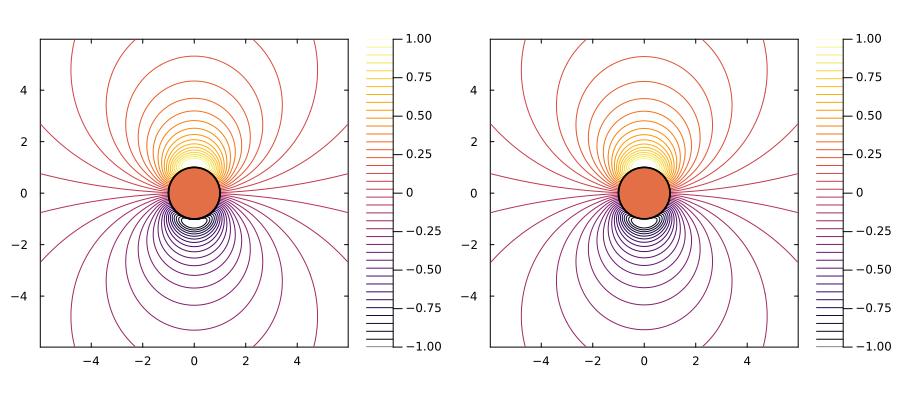

In [ ]:
p1 = plot(real(s1),sys1, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=true)
p2 = plot(real(s1_iner),cache, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=true)
plot(p1,p2,layout=(1,2),size=(900,400))

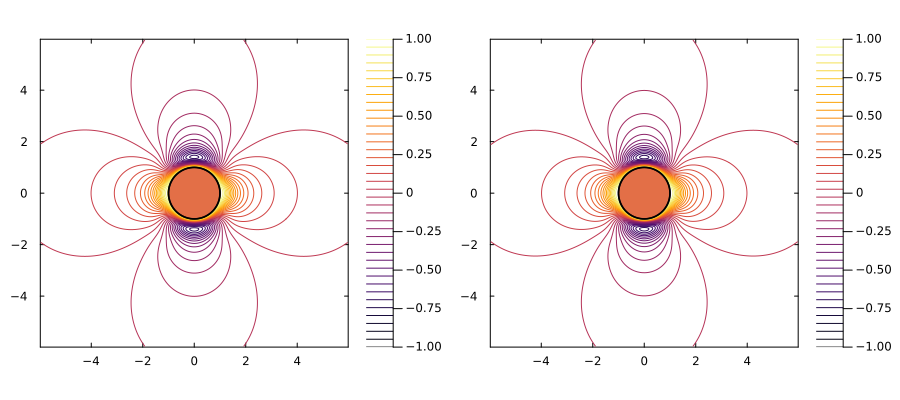

In [ ]:
p1 = plot(real(v1.u),sys1, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=true)
p2 = plot(real(v1_iner.u),cache, levels=range(-1,1,length=40),clim=(-1,1), cbar=true, xlim=(-Lx/2,Lx/2), ylim=(-Lx/2,Lx/2), bodyfill=true)
plot(p1,p2,layout=(1,2),size=(900,400))